# Notebook to explore the UWHVF dataset

In-depth description of the dataset: https://pubmed.ncbi.nlm.nih.gov/34978561/

In [12]:
import json
import numpy as np
from pathlib import Path
import polars as pl
import polars.selectors as cs
import seaborn as sns

In [3]:
UWHVF_DIR = Path("../data") / "UWHVF"
ALL_DATA_FILENAME = UWHVF_DIR / "alldata.json"
VF_DATA_FILENAME = UWHVF_DIR / "CSV" / "VF_Data.csv"

The data for Humphrey Visual Fields is available either in JSON format or in CSV format. 

## 1. Data - JSON format

In [85]:
# Load data
with open(ALL_DATA_FILENAME) as f:
  data = json.loads(f.read())

# Optional: pretty dump json to file
# with open(ALL_DATA_FILENAME, "w") as f:
#   json.dump(data, f, indent=4)

In [99]:
print(f"Num humphrey visual fields (HVFs): {data["hvfs"]}")
print(f"Num eyes: {data["eyes"]}")
print(f"Num patients: {data["pts"]}")
# print(f"Measured points in VF grid: {data["coords"]}")

Num humphrey visual fields (HVFs): 28943
Num eyes: 7428
Num patients: 3871


### Measurements for a patient

In [89]:
PATIENT_ID = '647'
EYE = 'R' # or 'L'
NUM_MEASUREMENTS = len(data["data"][PATIENT_ID][EYE])
print(f"Num measurements of the eye {EYE} for patient {PATIENT_ID}: {NUM_MEASUREMENTS}")

Num measurements of the eye R for patient 647: 11


### Humphrey Visual Field (HVF) and Total Deviation (TD) for a specific measurement

In [101]:
MEASUREMENT_ID = 0
print(f"Measurement: {MEASUREMENT_ID} (of {NUM_MEASUREMENTS}) for the eye {EYE} or patient {PATIENT_ID}")
AGE = data['data'][PATIENT_ID]['R'][MEASUREMENT_ID]['age']
print(f"Age of patient at measurement: {AGE}\n")

HVF = np.array(data['data'][PATIENT_ID]['R'][MEASUREMENT_ID]['hvf'])
print("Humphrey visual field:")
print(f"{HVF}\n")

TD = np.array(data['data'][PATIENT_ID]['R'][MEASUREMENT_ID]['td'])
print("Total deviation (difference in retinal sensitivity at each tested point compared to \n" \
"an age-matched normal database, expressed in decibels (dB)):")
print(TD)

Measurement: 0 (of 11) for the eye R or patient 647
Age of patient at measurement: 52.79671457905544

Humphrey visual field:
[[100.   100.   100.    26.34  23.73  22.84  24.19 100.   100.  ]
 [100.   100.    26.25  27.22  25.67  26.18  27.01  26.24 100.  ]
 [100.    22.2   28.17  29.2   28.44  27.58  28.51  28.02  25.68]
 [ 20.4   27.41  29.73  30.02  30.93  30.36  30.64  21.    27.89]
 [ 20.45  25.88  28.9   32.17  31.89  30.91  28.8    0.    27.43]
 [100.    27.16  29.98  32.74  29.95  32.07  29.84  26.99  27.3 ]
 [100.   100.    26.88  29.43  29.82  28.64  29.81  28.24 100.  ]
 [100.   100.   100.    28.88  27.3   26.82  28.18 100.   100.  ]]

Total deviation (difference in retinal sensitivity at each tested point compared to 
an age-matched normal database, expressed in decibels (dB)):
[[100.   100.   100.    -3.23  -5.88  -6.43  -4.72 100.   100.  ]
 [100.   100.    -4.77  -4.51  -6.26  -5.42  -4.09  -4.29 100.  ]
 [100.    -8.91  -4.39  -4.18  -5.29  -5.85  -4.3   -3.97  -5.51]
 

## 2. Data - CSV format

In [4]:
df = pl.read_csv(VF_DATA_FILENAME, schema_overrides={
        "Sens_35": pl.Float32
    })

In [ ]:
df.filter(pl.col("PatID") == int(PATIENT_ID))

PatID,Gender,Eye,FieldN,Age,Time_from_Baseline,MS,MS_Cluster1,MS_Cluster2,MS_Cluster3,MS_Cluster4,MS_Cluster5,MS_Cluster6,MTD,PSD,MTD_Cluster1,MTD_Cluster2,MTD_Cluster3,MTD_Cluster4,MTD_Cluster5,MTD_Cluster6,GH,Sens_1,Sens_2,Sens_3,Sens_4,Sens_5,Sens_6,Sens_7,Sens_8,Sens_9,Sens_10,Sens_11,Sens_12,Sens_13,Sens_14,Sens_15,…,PD_18,PD_19,PD_20,PD_21,PD_22,PD_23,PD_24,PD_25,PD_26,PD_27,PD_28,PD_29,PD_30,PD_31,PD_32,PD_33,PD_34,PD_35,PD_36,PD_37,PD_38,PD_39,PD_40,PD_41,PD_42,PD_43,PD_44,PD_45,PD_46,PD_47,PD_48,PD_49,PD_50,PD_51,PD_52,PD_53,PD_54
i64,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
647,"""F""","""Right""",1,52.7967,0.0,27.832885,25.5775,26.979231,30.588333,29.999,27.285455,27.075,-4.623269,1.509177,-4.6725,-5.453846,-3.933333,-3.73,-4.703636,-4.8725,-3.21,26.34,23.73,22.84,24.19,26.25,27.22,25.67,26.18,27.01,26.24,22.2,28.17,29.2,28.44,27.58,…,-2.3,-5.83,-1.27,-0.61,-1.24,-0.62,-0.91,0.0,"""NA""",-0.86,-5.83,-2.92,-1.57,0.7,0.05,-0.73,-2.13,"""NA""",-1.7,-1.14,0.09,1.85,-1.46,0.85,-0.78,-2.88,-1.79,-1.92,-0.36,-0.44,-1.52,-0.03,-1.06,0.75,-1.33,-2.02,-0.61
647,"""F""","""Right""",2,53.8234,1.0267,30.131346,27.76,29.911538,33.263333,32.018,29.544545,27.7875,-2.265192,1.611132,-2.41625,-2.456923,-1.2,-1.66,-2.392727,-4.1,-0.37,27.97,26.32,28.6,26.22,28.15,30.42,27.3,29.85,28.97,26.01,25.68,29.86,32.55,32.0,32.95,…,-4.75,-3.75,-3.61,-3.39,0.36,-0.52,0.6,-2.97,"""NA""",-3.91,-3.2,-3.91,-1.49,-0.1,0.93,0.08,-3.1,"""NA""",-2.0,-2.96,-0.53,0.55,-0.84,-0.75,-2.28,-4.19,-4.26,-0.54,-1.13,-1.81,-1.74,-2.19,-1.23,-4.85,-2.24,0.0,0.28
647,"""F""","""Right""",3,54.8857,2.089,29.454808,25.475,29.826154,32.488333,31.819,29.067273,26.8125,-2.879615,2.08078,-4.62625,-2.476154,-1.913333,-1.805,-2.813636,-5.015,-0.72,22.52,21.09,23.05,23.39,30.01,30.41,28.23,28.12,28.54,27.19,28.13,30.13,33.01,31.84,31.19,…,-3.74,-0.74,-2.75,-2.08,-1.15,-0.95,-0.43,-3.61,"""NA""",-2.94,-4.83,-2.28,-0.89,0.03,1.8,-0.19,-3.78,"""NA""",-5.66,-2.48,-0.22,0.0,0.33,-0.52,-5.28,-3.99,-4.84,-0.07,1.56,-2.09,0.07,-0.84,-2.45,-0.48,-4.1,-1.28,-4.07
647,"""F""","""Right""",4,57.7331,4.9363,27.947885,23.75625,28.658462,31.431667,30.611,26.899091,25.0225,-4.220192,2.19674,-6.13875,-3.467692,-2.805,-2.869,-4.837273,-6.6325,-1.64,23.07,20.61,21.03,20.71,29.04,27.68,27.84,26.33,25.5,22.3,26.34,31.43,32.91,30.53,29.82,…,-4.61,-6.36,-2.83,-0.79,0.22,-0.99,-0.21,-2.58,"""NA""",-4.35,-3.91,-2.64,-2.72,0.8,-0.6,0.19,-2.8,"""NA""",-6.41,-1.21,-1.13,0.78,-1.03,-0.58,-2.55,-6.5,-4.6,-2.57,-1.74,-0.52,-2.7,-1.48,-3.32,-3.0,-6.49,-2.19,-2.76
647,"""F""","""Right""",5,58.768,5.9713,27.644038,24.9025,28.104615,30.105,28.913,26.904545,26.8,-4.464231,1.84695,-4.92125,-3.956154,-4.073333,-4.515,-4.778182,-4.7975,-2.71,24.83,22.88,26.14,22.95,25.07,27.33,26.46,26.39,25.75,24.18,25.69,31.24,32.16,30.21,29.82,…,0.89,-7.64,-2.58,-0.25,0.43,-0.24,-1.1,-1.75,"""NA""",-1.29,-5.63,-2.39,-0.5,-0.15,0.66,-1.68,-4.07,"""NA""",-2.63,-0.4,-0.06,0.02,-0.93,-4.75,-3.66,-3.35,-5.32,-0.8,-0.93,-3.08,-2.55,-3.26,-3.13,-1.42,-0.18,-1.02,-2.63
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
647,"""F""","""Left""",7,63.7892,10.9925,23.796346,19.99875,22.661538,25.846667,25.815,24.6,24.7475,-8.019038,2.636976,-9.46375,-9.087692,-8.045,-7.359,-6.824545,-6.5525,-5.34,19.01,19.91,15.86,18.7,17.64,25.93,22.52,23.87,22.46,21.65,20.0,25.78,25.63,24.13,20.65,…,-0.42,-9.39,-3.3,-3.39,-6.96,-1.41,-3.42,-7.39,"""NA""",-0.39,-9.54,-4.74,-6.55,-1.77,-0.77,-1.31,-1.93,"""NA""",-1.59,-3.75,0.11,-0.25,0.0,-1.8,-1.93,-0.52,-2.45,0.22,1.39,-0.92,-2.34,0.66,-0.18,-3.01,1.23,-0.61,-2.22
647,"""F""","""Left""",8,64.2491,11.4524,24.243462,22.65375,21.982308,25.266667,25.666,25.511818,

In [ ]:

# We get the same HVF as in the JSON example above, + we can get the Mean Total Deviation value we'll use as a label
# for classification.

EYE = "Right"
# Select columns 'Sens_1' to 'Sens_54'
df_hvf = df.filter(
    pl.col("PatID") == int(PATIENT_ID),
    pl.col("Eye") == EYE
    ).select(
        cs.by_name("MTD") | cs.starts_with("Sens_")
    )
df_hvf.row(MEASUREMENT_ID)[:10]

(-4.62326923076923,
 26.34,
 23.73,
 22.84,
 24.19,
 26.25,
 27.22,
 25.67,
 26.18,
 27.01)

### Distribution of Classes

<Axes: ylabel='Count'>

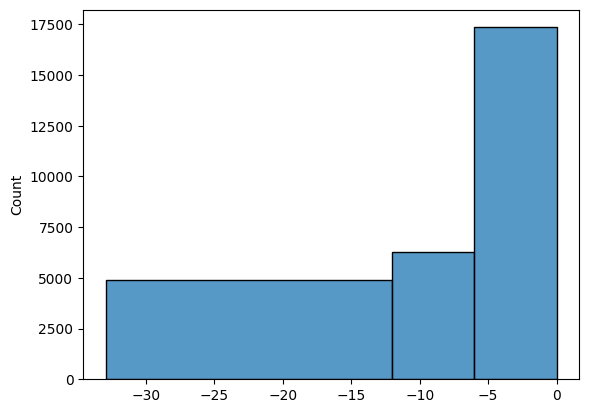

In [ ]:
MTD = df.select("MTD").to_numpy().flatten()
db_bins = [MTD.min(), -12, -6, 100]
sns.histplot(MTD, bins=db_bins)